# 2D Implmentation of the Helmoltz solver

2D Helmholtz Equation: Finite Difference Derivation and Spectral Decomposition

The 2D Helmholtz equation is:

$$
\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} + k^2 u = f(x, y)
$$

Discretization
* Domain: Split into an $ N \times M $ grid with spacing $ h = \frac{1}{N+1} $ in $ x $ and $ y $.
* Let $ u_{i,j} \approx u(x_i, y_j) $ and $ f_{i,j} = f(x_i, y_j) $, where $ x_i = ih $ and $ y_j = jh $.


Central Difference Approximation
The second derivatives are approximated as:

$$
\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i-1,j} - 2u_{i,j} + u_{i+1,j}}{h^2}, \quad \frac{\partial^2 u}{\partial y^2} \approx \frac{u_{i,j-1} - 2u_{i,j} + u_{i,j+1}}{h^2}
$$

Substituting into the Helmholtz Equation
$$
\frac{u_{i-1,j} + u_{i+1,j} + u_{i,j-1} + u_{i,j+1} - 4u_{i,j}}{h^2} + k^2 u_{i,j} = f_{i,j}
$$

Rearranging gives the linear equation for interior points:

$$
\frac{1}{h^2}u_{i-1,j} + \frac{1}{h^2}u_{i+1,j} + \frac{1}{h^2}u_{i,j-1} + \frac{1}{h^2}u_{i,j+1} + \left(\frac{-4}{h^2} + k^2\right)u_{i,j} = f_{i,j}
$$

Spectral Decomposition in the $ y $-Direction
To preserve the tridiagonal structure, decompose the problem using the Discrete Sine Transform (DST)} for Dirichlet BCs (or DCT for Neumann BCs):

Forward DST on $ f(x, y) $
* For each column $ x_i $, compute the spectral coefficients:
$$
\tilde{f}_{i,m} = \text{DST}\left[f_{i,j}\right] = \sum_{j=1}^{N_y-1} f_{i,j} \sin\left(\frac{m \pi j}{N_y}\right)
$$
This diagonalizes the $ y $-Laplacian into eigenvalues $ \lambda_m^{(y)} = -\frac{4}{h^2} \sin^2\left(\frac{m \pi h}{2L_y}\right) $.

Modified 1D Helmholtz Equations in $ x $:

For each mode $ m $, solve:
$$
\frac{d^2 \tilde{u}_m}{dx^2} + \left(k^2 - \lambda_m^{(y)}\right)\tilde{u}_m = \tilde{f}_m(x)
$$
*This is a tridiagonal system} identical to the 1D case, with effective wavenumber $ k_{\text{eff}}^2 = k^2 - \lambda_m^{(y)} $.

Matrix Form for Each Mode}

*For each $ m $, the tridiagonal matrix $ A_m $ has:

* Diagonal entries: $ \frac{-2}{h^2} + k_{\text{eff}}^2 $
* Off-diagonal entries: $ \frac{1}{h^2} $
* Solve $ A_m \tilde{u}_m = \tilde{f}_m $ using your 1D solver.

Inverse DST to Reconstruct $ u(x, y) $}

*For each column $ x_i $, compute:
$$
u_{i,j} = \text{Inverse DST}\left[\tilde{u}_{i,m}\right] = \frac{2}{N_y+1} \sum_{m=1}^{N_y-1} \tilde{u}_{i,m} \sin\left(\frac{m \pi j}{N_y}\right)
$$

Matrix Structure Summary

* Original 2D System: Block tridiagonal (not directly solvable with a 1D tridiagonal solver).
* After Spectral Decomposition}: Independent 1D tridiagonal systems for each mode $ m $.
* Key Advantage: Retains the efficiency of your 1D code by reducing the 2D problem to $ M $ 1D solves.




Import the necessary modules

In [1]:
# make use of QLS jupyter env
import numpy as np
import scipy as sc
from linear_solvers import NumPyLinearSolver, HHL
from linear_solvers.matrices.tridiagonal_toeplitz import TridiagonalToeplitz
from linear_solvers.matrices.numpy_matrix import NumPyMatrix
from numerical_solvers.thomas_algorithm import numerical_solvers
from qiskit.quantum_info import Statevector
from qiskit import Aer, transpile
from scipy.sparse import diags
from scipy.fft import dst, idst
import matplotlib.pyplot as plt
import seaborn as sns

Define the Utility functions which we will need:

In [2]:
def normalize(arr, t_min, t_max):
    """
    Normalize an array to a specified range [t_min, t_max].
    
    For data that spans both negative and positive values, this function
    uses a symmetric normalization (dividing by the maximum absolute value)
    to preserve the zero-crossing and the relative oscillatory behavior.
    
    For data that does not span both signs, it uses standard min-max normalization.
    """
    arr = np.array(arr)
    # Check if data spans both negative and positive values
    # Use symmetric normalization:
    max_abs = np.max(np.abs(arr))
    # Avoid division by zero
    if max_abs < 1e-12:
        norm_arr = arr.copy()
    else:
        norm_arr = arr / max_abs
    # If the target range is symmetric about zero (e.g., [-1, 1]),
    # then simply scale by the maximum absolute value.
    # Otherwise, map [-1, 1] to [t_min, t_max]:
    if t_min == -1 and t_max == 1:
        return norm_arr
    else:
        # Mapping from [-1,1] to [t_min, t_max]:
        return ((norm_arr + 1) / 2) * (t_max - t_min) + t_min
    
    
def get_solution_vector(solution, N, vector):
    """Extracts and normalizes simulated state vector from LinearSolverResult."""
    start = 2**(N-1)
    fin = 2**(N-1) + len(vector)
    solution_vector = Statevector(solution.state).data[start:fin].real
    norm = solution.euclidean_norm
    return norm*solution_vector / np.linalg.norm(solution_vector)

def construct_TT_matrix(main_diag, off_diag, size):
    '''
    Construct a tridiagonal Toeplitz matrix using the main diagonal and off-diagonal elements.
    '''
    matrix = diags([off_diag, main_diag, off_diag], offsets=[-1, 0, 1], shape=(size, size)).toarray()
    return matrix

def solve_1DHHL(matrix, vector, qubits, epsilon=0.01):
    '''
    Solves the 1D HHL
    '''
    a = matrix[0, 0]
    b = matrix[0, 1]
    
    tridi_mat = TridiagonalToeplitz(qubits, a, b)
    hhl_solver = HHL(epsilon=epsilon)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, vector)
    hhl_interior = get_solution_vector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, vector)
    #hhl_vector = np.concatenate(([0], hhl_interior, [0]))
    #hhl_sol = normalize(hhl_vector, -1.0, 1.0)
    #print('computed hhl solution\n', hhl_sol)
    return hhl_interior

def solve_1DThomas(matrix, vector):
    '''
    Solves the 1D Thomas algorithm
    '''
    
    # Compare to thomas
    thomas = numerical_solvers()
    num_solution = thomas.solve_tridiagonal_thomas(matrix, vector)
    #num_solution = np.concatenate(([0], num_solution, [0]))
    #num_solution = normalize(num_solution, -1.0, 1.0)
    return num_solution
   

Define the Simulation parameters

In [16]:
# Domain specifications
Lx = 1.0       # Length of the x-dimension
Ly = 1.0       # Length of the y-dimension
NUM_QUBITS = 3 # Number of qubits used to represent the solution
N = 2**NUM_QUBITS  # Number of interior grid points in each dimension
N_total = N + 2    # Total grid points including boundaries

dx = Lx / (N + 1)  # Grid spacing (consistent with N interior points)
dy = Ly / (N + 1)

# Create full grid including boundaries
x_vals = np.linspace(0, Lx, N_total)
y_vals = np.linspace(0, Ly, N_total)

# Extract interior points (excluding boundaries)
interior_x = x_vals[1:-1]
interior_y = y_vals[1:-1]
interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

# PDE specifications
k = 6.0  # Wave Number

# Evaluate forcing function only on the interior grid points
f_interior = np.sin(np.pi * 2 * interior_X) * np.sin(2 * np.pi * interior_Y)


In [17]:
# First decomposition of the Laplacian
m_modes = np.arange(1, N+1)
# Compute the eigenvalues of the y - Laplacian
lambda_y = -4 / dy**2 * np.sin(m_modes * np.pi * dy / (2 * Ly))**2 

f_hat = dst(f_interior, axis=1, type=1, norm='ortho')  # Apply DST along y
#print(f_hat)

u_hat = np.zeros((N, N))
thomas_u_hat = np.zeros((N, N))
print('Need to compute: ' , len(m_modes), 'modes')

for m in range(len(m_modes)):
        if np.linalg.norm(f_hat[:, m]) < 1e-12:
                u_hat[:, m] = 0
                print('Skipping mode m =', m)
                continue
        
        k_eff_sq = k**2 - lambda_y[m]
        print('Solving for mode m =', m)
        
        main_diag = -2/dx**2 + k_eff_sq
        off_diag = 1/dx**2
        A = construct_TT_matrix(main_diag, off_diag, size=N)
        
        print('matrix conditon number\n', np.linalg.cond(A))  
        #print('computed matrix A\n', A)  
        #print('f_hat[:, m] norm \n', np.linalg.norm(f_hat[:, m]))
        
        u_hat[:, m] = solve_1DHHL(A, f_hat[:, m], NUM_QUBITS)
 
        # Thomas algorithm
        thomas_u_hat[:, m] = solve_1DThomas(A, f_hat[:, m])
        


Need to compute:  8 modes
Skipping mode m = 0
Solving for mode m = 1
matrix conditon number
 33.853027330079634
Updated trotter steps to 5155
Updated trotter steps to 8

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  7

 Number of b qubits 
:  3
Skipping mode m = 2
Skipping mode m = 3
Skipping mode m = 4
Skipping mode m = 5
Skipping mode m = 6
Skipping mode m = 7


now try and compute the inverse

In [18]:
#print(' u_hat\n', u_hat)
#print('thomas_u_hat\n', thomas_u_hat)
u = idst(u_hat, axis=1, type=1, norm='ortho')  # Apply inverse DST along y
thomas_u = idst(thomas_u_hat, axis=1, type=1, norm='ortho')  # Apply inverse DST along y
#print(' u after inverse dst\n', u)
#print('thomas_u after inverse dst\n', thomas_u)
# add dirichlet boundary values to zero at the boundaries
u = np.pad(u, ((0, 0), (1, 1)), mode='constant', constant_values=0)
u = np.pad(u, ((1, 1), (0, 0)), mode='constant', constant_values=0)

thomas_u = np.pad(thomas_u, ((0, 0), (1, 1)), mode='constant', constant_values=0)
thomas_u = np.pad(thomas_u, ((1, 1), (0, 0)), mode='constant', constant_values=0)

#print('computed solution\n', u)
#print('computed thomas solution\n', thomas_u)

Output the 3D surface

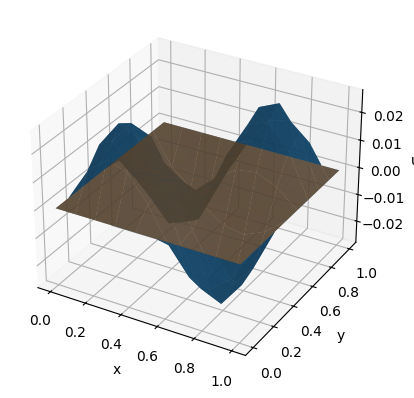

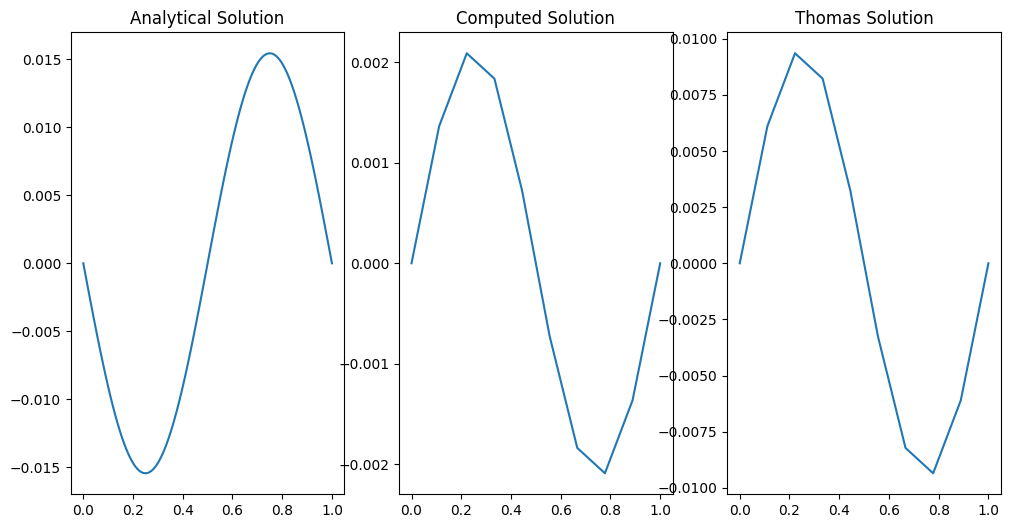

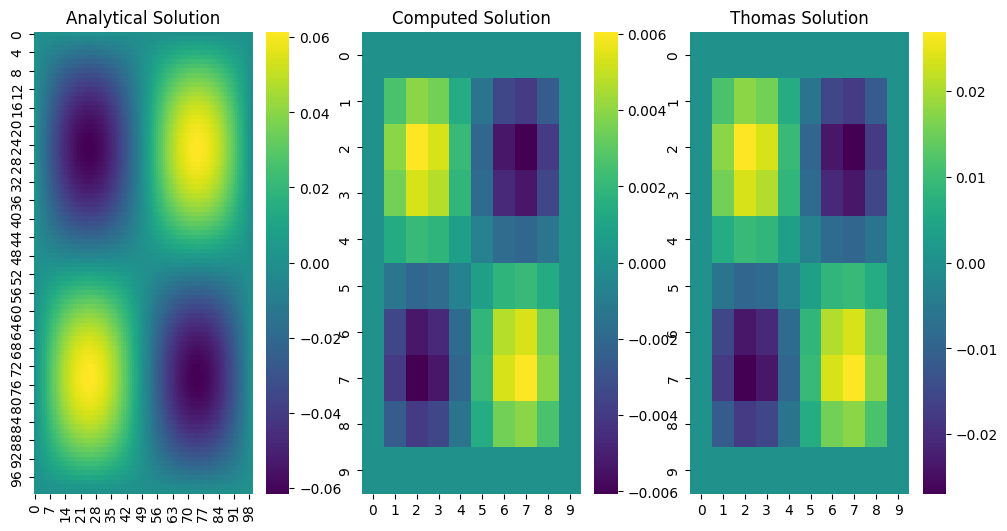

In [19]:
# compute the analytical solution
# make a high resolution grid
X_high_res, Y_high_res = np.meshgrid(np.linspace(0, Lx, 100), np.linspace(0, Ly, 100), indexing='ij')
u_analytical = np.sin(np.pi * 2 * X_high_res) * np.sin(2 * np.pi * Y_high_res) / (2 * np.pi**2 - k**2)

x_vals = np.linspace(0, Lx, N+2)
y_vals = np.linspace(0, Ly, N+2)
X_full, Y_full = np.meshgrid(x_vals, y_vals, indexing='ij')


# output to a 3D surface plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
#ax.plot_surface(X_high_res, Y_high_res, u_analytical, alpha=0.8)
ax.plot_surface(X_full, Y_full, thomas_u, alpha=0.8)
ax.plot_surface(X_full, Y_full, u, alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u')
plt.show()

# plot the side view of the computed solution and analytic
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title('Analytical Solution')
plt.plot(X_high_res[:, 0], u_analytical[N//2, :])
plt.subplot(1, 3, 2)
plt.title('Computed Solution')
plt.plot(X_full[:, 0], u[N//2,:])
plt.subplot(1, 3, 3)
plt.title('Thomas Solution')
plt.plot(X_full[:, 0], thomas_u[N//2,:])
plt.show()

# plot the contour plot of the computed solution side by side
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title('Analytical Solution')
sns.heatmap(u_analytical, cmap='viridis')
plt.subplot(1, 3, 2)
plt.title('Computed Solution')
sns.heatmap(u, cmap='viridis')
plt.subplot(1, 3, 3)
plt.title('Thomas Solution')
sns.heatmap(thomas_u, cmap='viridis')
plt.show()
